In [17]:
from Bio import Entrez, SeqIO
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time

Entrez.email='lcarmonav10@gmail.com'
print('Librerías listas')

Librerías listas


In [4]:
search = Entrez.esearch(
    db = 'nucleotide',
    term = 'TP53[Gene] AND Homo sapiens[Organism] AND mRNA[Filter]',
    retmax = 20
)

result = Entrez.read(search)
ids = result['IdList']
print(f'secuencias encontradas: {len(ids)}')
print('IDS: ', ids)

secuencias encontradas: 20
IDS:  ['3211419055', '3135759503', '3135759501', '3135759499', '1894803104', '1894803103', '1894803100', '1894803099', '1894803061', '1894803053', '1894803042', '1890336258', '1890334252', '1890275790', '1889734158', '1889662456', '1889531459', '1889514023', '1808862652', '2967564311']


In [8]:
handle = Entrez.efetch(
    db='nucleotide',
    id=ids,
    rettype='fasta',
    retmode='text'
)

#Creating Fasta File.
with open('tp53_secuencias.fasta', 'w') as f:
    f.write(handle.read())

print('Archivo FASTA guardado correctamente')

Archivo FASTA guardado correctamente


In [15]:
# This is to save the data of each sequence
registers = []

for seq_record in SeqIO.parse('tp53_secuencias.fasta', 'fasta'):
    seq = str(seq_record.seq).upper()
    length = len(seq)

    registers.append({'id': seq_record.id, 
                  'length': length,
                  'A': seq.count('A'),
                  'T': seq.count('T'),
                  'G': seq.count('G'),
                  'C': seq.count('C'),
                  'pct_A': round(seq.count('A') / length * 100, 2),
                  'pct_T': round(seq.count('T') / length * 100, 2),
                  'pct_G': round(seq.count('G') / length * 100, 2),
                  'pct_C': round(seq.count('C') / length * 100, 2),
                  'content_GC': round((seq.count('G') + seq.count('C')) / length * 100, 2)
                 })

# Creating Data Frame with Panda.
df = pd.DataFrame(registers)
print(f'Secuencias analizadas: {len(df)}')
df.head()

Secuencias analizadas: 20


,id,length,A,T,G,C,pct_A,pct_T,pct_G,pct_C,content_GC
0,PZ086170.1,123,23,20,35,45,18.70,16.26,28.46,36.59,65.04
1,PX584652.1,1182,275,234,307,366,23.27,19.80,25.97,30.96,56.94
2,PX584651.1,1182,277,233,306,366,23.43,19.71,25.89,30.96,56.85
3,PX584650.1,1182,277,234,305,366,23.43,19.80,25.80,30.96,56.77
4,NM_001126117.2,2063,449,553,500,561,21.76,26.81,24.24,27.19,51.43


In [16]:
print('=== Gene TP53 Stats ===')
print(f'Average length: {df["length"].mean():.0f} nucleótidos')
print(f'Average GC content: {df["content_GC"].mean():.2f}%')
print(f'Longest sequence: {df["length"].max()} nt')
print(f'Shorter sequence: {df["length"].min()} nt')
print()
print('Average of each nucleotid')
for nuc in ['pct_A', 'pct_T', 'pct_G', 'pct_C']:
    print(f'{nuc[-1]}:{df[nuc].mean():.2f}%') 

=== Gene TP53 Stats ===
Average length: 2018 nucleótidos
Average GC content: 53.95%
Longest sequence: 2645 nt
Shorter sequence: 123 nt

Average of each nucleotid
A:21.79%
T:24.26%
G:24.96%
C:28.99%


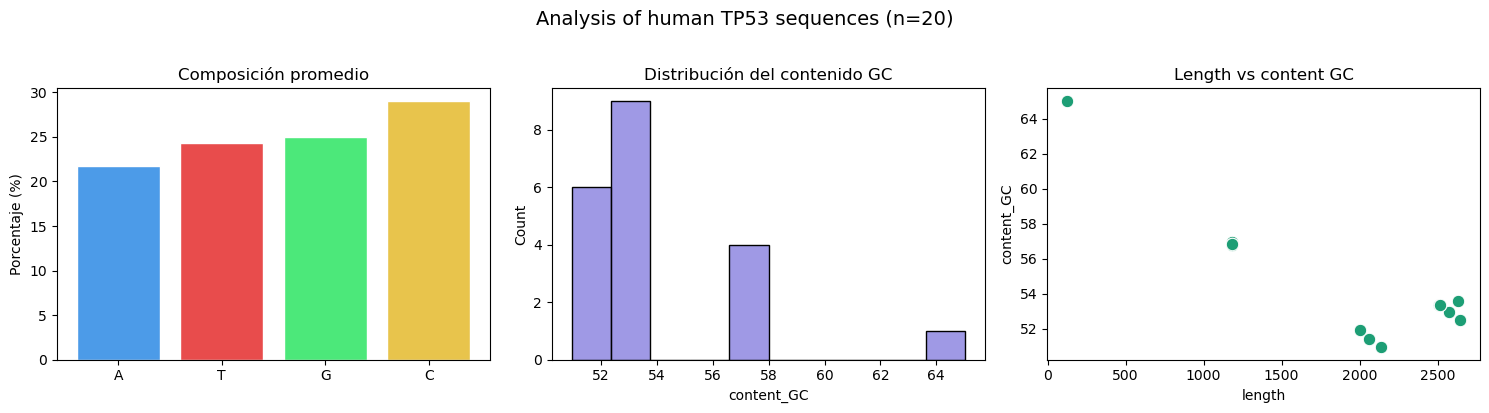

In [23]:
# Canvas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Style
nucs = ['pct_A', 'pct_T', 'pct_G', 'pct_C']
colors = ['#4C9BE8', '#E84C4C', '#4CE87A', '#E8C44C']

# Graph 1: Composition Bars
axes[0].bar(['A','T','G','C'],
            [df[n].mean() for n in nucs],
            color=colors, edgecolor='white')
axes[0].set_title('Composición promedio')
axes[0].set_ylabel('Porcentaje (%)')

# Graph 2: GC Distribution.
sns.histplot(data=df, x='content_GC',
             bins=10, color='#7F77DD', ax=axes[1])
axes[1].set_title('Distribución del contenido GC')

# Graph 3: Length vs GC
sns.scatterplot(data=df, x='length', y='content_GC',
                color='#1D9E75', s=80, ax=axes[2])
axes[2].set_title('Length vs content GC')

plt.suptitle('Analysis of human TP53 sequences (n=20)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('tp53_analisis.png', dpi=150, bbox_inches='tight')
plt.show()